# Pull Arxiv papers utilizing Arxiv API

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arxiv
from datetime import datetime, timedelta

In [14]:
client = arxiv.Client(
  page_size = 500,
  delay_seconds = 10.0,
  num_retries = 5
)

In [15]:
end = datetime.now()
start = end - timedelta(days=365)

start_str = start.strftime('%Y%m%d')
end_str = end.strftime('%Y%m%d')

search = arxiv.Search(
    query=f"(cat:cs.LG OR cat:cs.AI OR cat:cs.CL OR cat:cs.CV OR cat:cs.NE OR cat:cs.IR) AND submittedDate:[{start_str} TO {end_str}]",
    max_results=10000
)

results = client.results(search)

df = pd.DataFrame([{
    "id": result.get_short_id().split("v")[0],
    "title": result.title.strip(),
    "first_author": result.authors[0].name if result.authors else None,
    "authors": [a.name for a in result.authors] if result.authors else [],
    "published": result.published,
    "updated": result.updated,
    "primary_category": result.primary_category,
    "categories": result.categories if result.categories else [],
    "abstract": result.summary.strip() if result.summary else None,
    "link_url": result.entry_id or None,
    "pdf_url": result.pdf_url
} for result in results])

In [16]:
print(df.shape)
print(df.dtypes)
df.sort_values(by="published", inplace=True, ignore_index=True)
df

(10000, 11)
id                                  str
title                               str
first_author                        str
authors                          object
published           datetime64[us, UTC]
updated             datetime64[us, UTC]
primary_category                    str
categories                       object
abstract                            str
link_url                            str
pdf_url                             str
dtype: object


,id,title,first_author,authors,published,updated,primary_category,categories,abstract,link_url,pdf_url
0,2505.12581,An approach based on class activation maps for...,Lucas M. Dorneles,"[Lucas M. Dorneles, Luan Fonseca Garcia, Joel ...",2025-05-19 00:03:57+00:00,2025-05-19 00:03:57+00:00,cs.LG,"[cs.LG, cs.AI, cs.CV]",Neural networks have become increasingly popul...,http://arxiv.org/abs/2505.12581v1,https://arxiv.org/pdf/2505.12581v1
1,2505.12585,Learning Robust Spectral Dynamics for Temporal...,En Yu,"[En Yu, Jie Lu, Xiaoyu Yang, Guangquan Zhang, ...",2025-05-19 00:38:18+00:00,2025-05-19 00:38:18+00:00,cs.LG,"[cs.LG, cs.AI]",Modern machine learning models struggle to mai...,http://arxiv.org/abs/2505.12585v1,https://arxiv.org/pdf/2505.12585v1
2,2505.13544,Multi-head Temporal Latent Attention,Keqi Deng,"[Keqi Deng, Philip C. Woodland]",2025-05-19 02:09:41+00:00,2025-11-02 20:27:27+00:00,cs.LG,"[cs.LG, cs.AI]",While Transformer self-attention offers strong...,http://arxiv.org/abs/2505.13544v3,https://arxiv.org/pdf/2505.13544v3
3,2505.12626,scSiameseClu: A Siamese Clustering Framework f...,Ping Xu,"[Ping Xu, Zhiyuan Ning, Pengjiang Li, Wenhao L...",2025-05-19 02:17:09+00:00,2025-10-02 02:55:07+00:00,q-bio.GN,"[q-bio.GN, cs.AI, cs.LG]",Single-cell RNA sequencing (scRNA-seq) reveals...,http://arxiv.org/abs/2505.12626v3,https://arxiv.org/pdf/2505.12626v3
4,2505.12632,Scalable Video-to-Dataset Generation for Cross...,Yunseok Jang,"[Yunseok Jang, Yeda Song, Sungryull Sohn, Laja...",2025-05-19 02:39:03+00:00,2025-05-19 02:39:03+00:00,cs.CV,"[cs.CV, cs.AI, cs.CL, cs.LG]",Recent advancements in Large Language Models (...,http://arxiv.org/abs/2505.12632v1,https://arxiv.org/pdf/2505.12632v1
...,...,...,...,...,...,...,...,...,...,...,...
9995,2605.18663,GIM: Evaluating models via tasks that integrat...,Rohit Patel,"[Rohit Patel, Alexandre Rezende, Steven McClain]",2026-05-18 17:09:50+00:00,2026-05-18 17:09:50+00:00,cs.AI,"[cs.AI, cs.CL, cs.LG]","As LLM benchmarks saturate, the evaluation com...",http://arxiv.org/abs/2605.18663v1,https://arxiv.org/pdf/2605.18663v1
9996,2605.18732,Predictable Confabulations: Factual Recall by ...,Matthew L. Smith,"[Matthew L. Smith, Jonathan P. Shock, Samuel T...",2026-05-18 17:53:44+00:00,2026-05-18 17:53:44+00:00,cs.CL,"[cs.CL, cs.AI, cs.LG]",While scaling laws govern aggregate large lang...,http://arxiv.org/abs/2605.18732v1,https://arxiv.org/pdf/2605.18732v1
9997,2605.18740,Vision-OPD: Learning to See Fine Details for M...,Qianhao Yuan,"[Qianhao Yuan, Jie Lou, Xing Yu, Hongyu Lin, L...",2026-05-18 17:57:04+00:00,2026-05-18 17:57:04+00:00,cs.CV,"[cs.CV, cs.AI, cs.CL, cs.LG]",Multimodal Large Language Models (MLLMs) still...,http://arxiv.org/abs/2605.18740v1,https://arxiv.org/pdf/2605.18740v1
9998,2605.18746,ESI-Bench: Towards Embodied Spatial Intelligen...,Yining Hong,"[Yining Hong, Jiageng Liu, Han Yin, Manling Li...",2026-05-18 17:59:02+00:00,2026-05-18 17:59:02+00:00,cs.CV,"[cs.CV, cs.AI, cs.CL, cs.LG, cs.RO]",Spatial intelligence unfolds through a percept...,http://arxiv.org/abs/2605.18746v1,https://arxiv.org/pdf/2605.18746v1


In [17]:
df['primary_category'].value_counts()

primary_category
cs.LG       2679
cs.CL       2437
cs.CV       2399
cs.AI        899
cs.IR        493
            ... 
math.CO        1
q-bio.OT       1
q-fin.GN       1
hep-ex         1
stat.AP        1
Name: count, Length: 66, dtype: int64

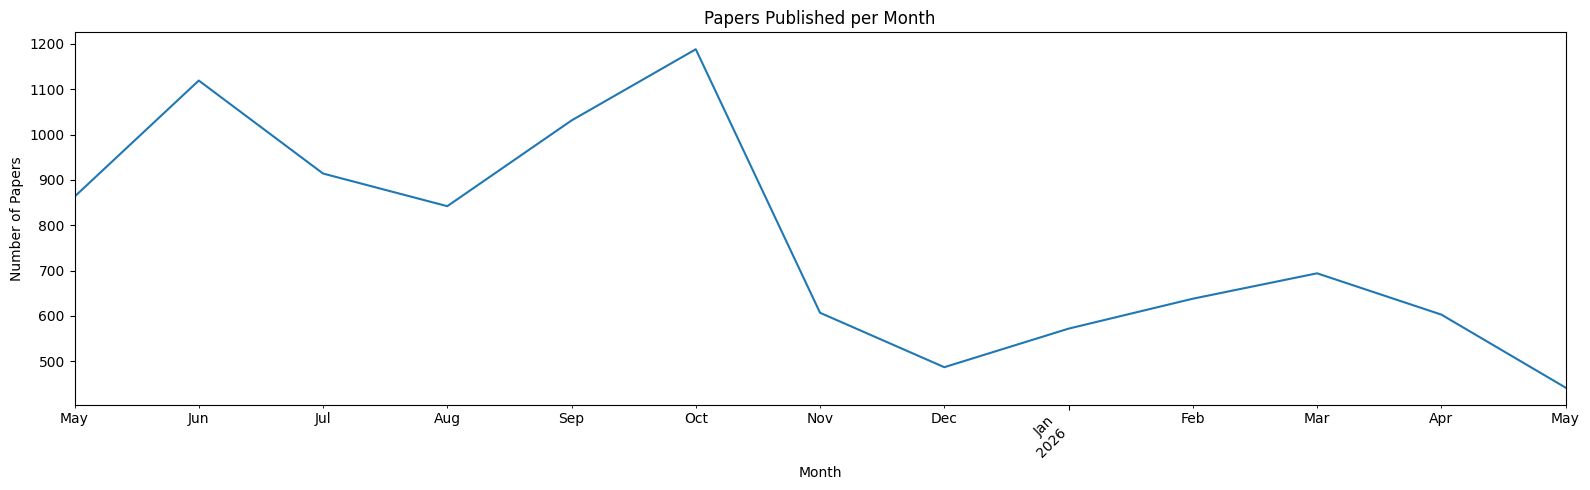

In [18]:
df['published'] = pd.to_datetime(df['published']).dt.tz_localize(None)

monthly_grouped = df.groupby(df['published'].dt.to_period('M')).size()

monthly_grouped.plot(kind='line', figsize=(16, 5))
plt.xlabel('Month')
plt.ylabel('Number of Papers')
plt.title('Papers Published per Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

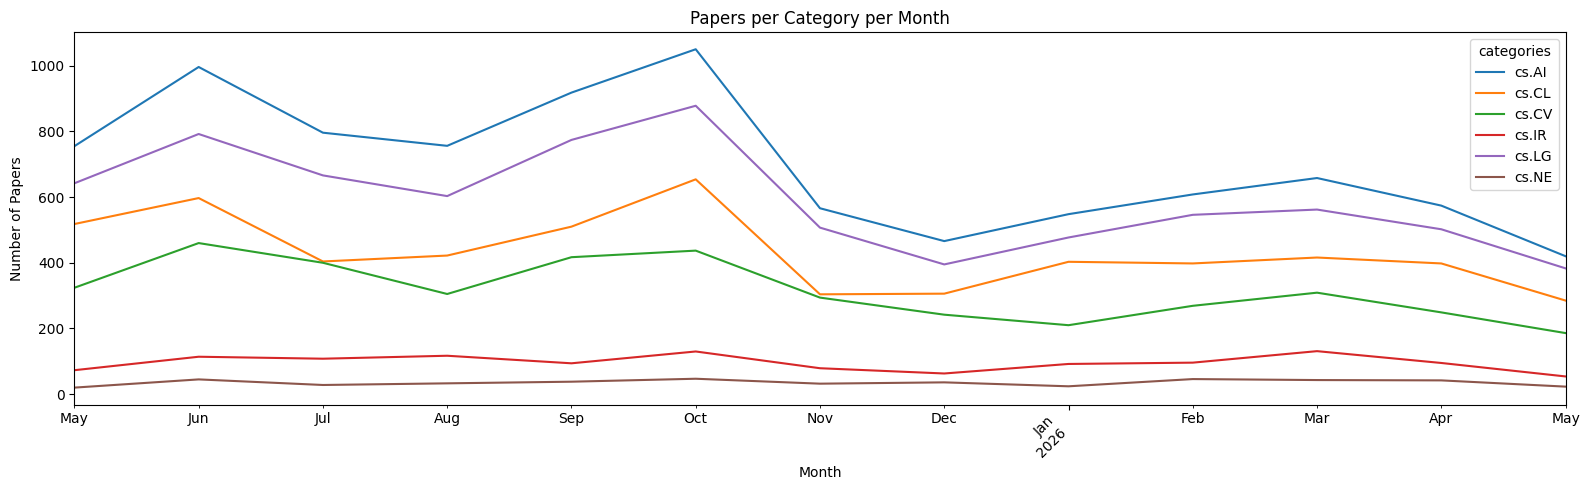

In [19]:
df_exploded = df.reset_index(drop=True).explode('categories')

main_categories = [
    "cs.LG",    # Machine Learning
    "cs.CV",    # Computer Vision
    "cs.CL",    # Computation & Language
    "cs.AI",    # Artificial Intelligence
    "cs.NE",    # Neural & Evolutionary Computing
    "cs.IR",    # Information Retrieval
]

filtered = df_exploded[df_exploded['categories'].isin(main_categories)].copy()

(
    filtered
    .groupby([filtered['published'].dt.to_period('M'), 'categories'])
    .size()
    .unstack('categories')
    .plot(figsize=(16, 5), title='Papers per Category per Month')
)

plt.xlabel('Month')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
df.to_csv("data/arxiv_papers.csv", index=False)